In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel('online_retail.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print("Size:", df.shape)
print("\nType:")
print(df.dtypes)
print("\nLeft:")
print(df.isnull().sum())

Size: (525461, 8)

Type:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Left:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [4]:
df.shape



(525461, 8)

In [5]:
df['Total Price'] = df['Quantity'] * df['Price']
df.head() 

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
avg_purchase = df['Total Price'].mean() 
print(f"Average purchase value (per line item): {avg_purchase:.2f}")

Average purchase value (per line item): 18.15


In [7]:
purchase_freq = df.groupby('Customer ID')['Invoice'].nunique()
print(f"Average purchase frequency (orders per customer): {purchase_freq.mean():.2f}")

Average purchase frequency (orders per customer): 5.38


In [8]:
customer_value = df.groupby('Customer ID')['Total Price'].sum()
print(f"Average Customer Lifetime Value: {customer_value.mean():.2f}")

Average Customer Lifetime Value: 1904.68


## Descriptive Statistics

The average purchase value per line item is £18.15. Customers place 
an average of 5.38 orders each, and the average Customer Lifetime 
Value (total spend per customer) is £1904.68 — though this average 
is likely skewed upward by a small number of very high-spending 
customers, which the clustering analysis below will help identify.

In [9]:
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Total Price': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM table size:", rfm.shape)
rfm.describe()

Snapshot date: 2010-12-10 20:01:00


RFM table size: (4312, 3)


,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


In [11]:
print("df size right before RFM:", df.shape)
print("Min Quantity:", df['Quantity'].min())
print("Min Price:", df['Price'].min())
print("Min Total Price:", df['Total Price'].min())

df size right before RFM: (407664, 9)
Min Quantity: 1
Min Price: 0.001
Min Total Price: 0.001


## Feature Selection: RFM Analysis

Three key behavioural features were selected for clustering, following 
the RFM framework: Recency (days since last purchase), Frequency 
(number of distinct orders), and Monetary (total amount spent). 
These three metrics together capture how recently, how often, and 
how much each customer buys — the core dimensions needed to identify 
meaningful customer segments.

In [12]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled[:5]

array([[ 0.76229851,  0.80108727, -0.18796074],
       [-0.91040156, -0.3006029 , -0.0813286 ],
       [-0.17730462, -0.42301292, -0.20486778],
       [-0.4973892 , -0.17819288,  0.06988337],
       [-0.82779909, -0.42301292, -0.19603057]])

In [13]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.312000e+03,4.312000e+03,4.312000e+03
mean,5.602610e-17,5.932175e-17,-2.306957e-17
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-9.310522e-01,-4.230129e-01,-2.294610e-01
25%,-7.555219e-01,-4.230129e-01,-1.952388e-01
50%,-3.941361e-01,-3.006029e-01,-1.505835e-01
75%,4.628645e-01,6.662716e-02,-3.647250e-02
max,2.920288e+00,2.454863e+01,3.894297e+01


## Data Standardisation

Before applying K-Means, the RFM features were standardised using 
StandardScaler so that each feature (Recency, Frequency, Monetary) 
contributes equally to the clustering — without this step, Monetary 
(values in the thousands) would dominate over Recency and Frequency 
(values in the tens/hundreds) simply due to scale, not actual 
importance.

In [16]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

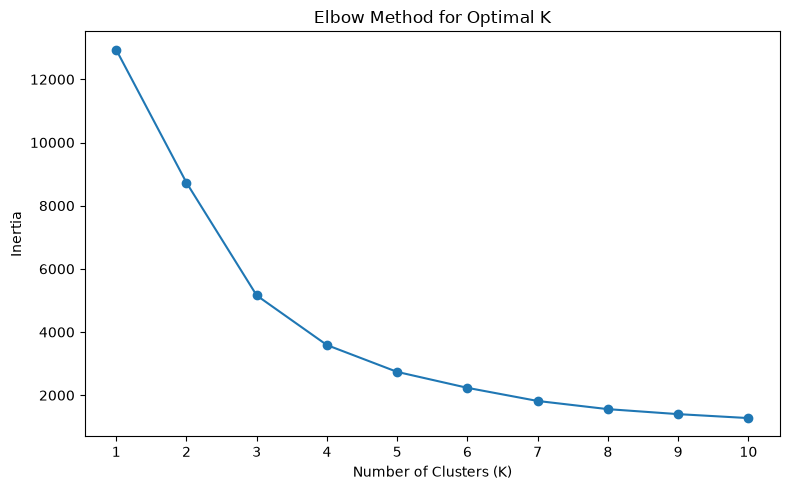

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,1
12347.0,3,2,1323.32,0
12348.0,74,1,222.16,0
12349.0,43,3,2671.14,0
12351.0,11,1,300.93,0


## K-Means Clustering: Elbow Method

The Elbow Method was used to determine the optimal number of clusters. 
Inertia drops sharply from K=1 to K=3, with a visible bend (elbow) 
around K=4, after which additional clusters yield diminishing returns 
in reducing inertia. Based on this, K=4 was selected as the optimal 
number of clusters for this analysis.